In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.108  Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
Setup complete  (8 CPUs, 7.8 GB RAM, 217.7/450.7 GB disk)


In [3]:
from ultralytics import YOLO
from IPython.display import Image

In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="sLzSeXuNKKwLQff3ci4n")
project = rf.workspace("project-uyrxf").project("ppe_detection-v1x3l")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [7]:
dataset.location

'c:\\Users\\Karan\\Desktop\\PPE_DETECTION\\PPE_Detection-2'

In [ ]:
!yolo task=detect mode=train data={dataset.location}/data.yaml  model="yolo11n.pt" epochs=20 imgsz=300  

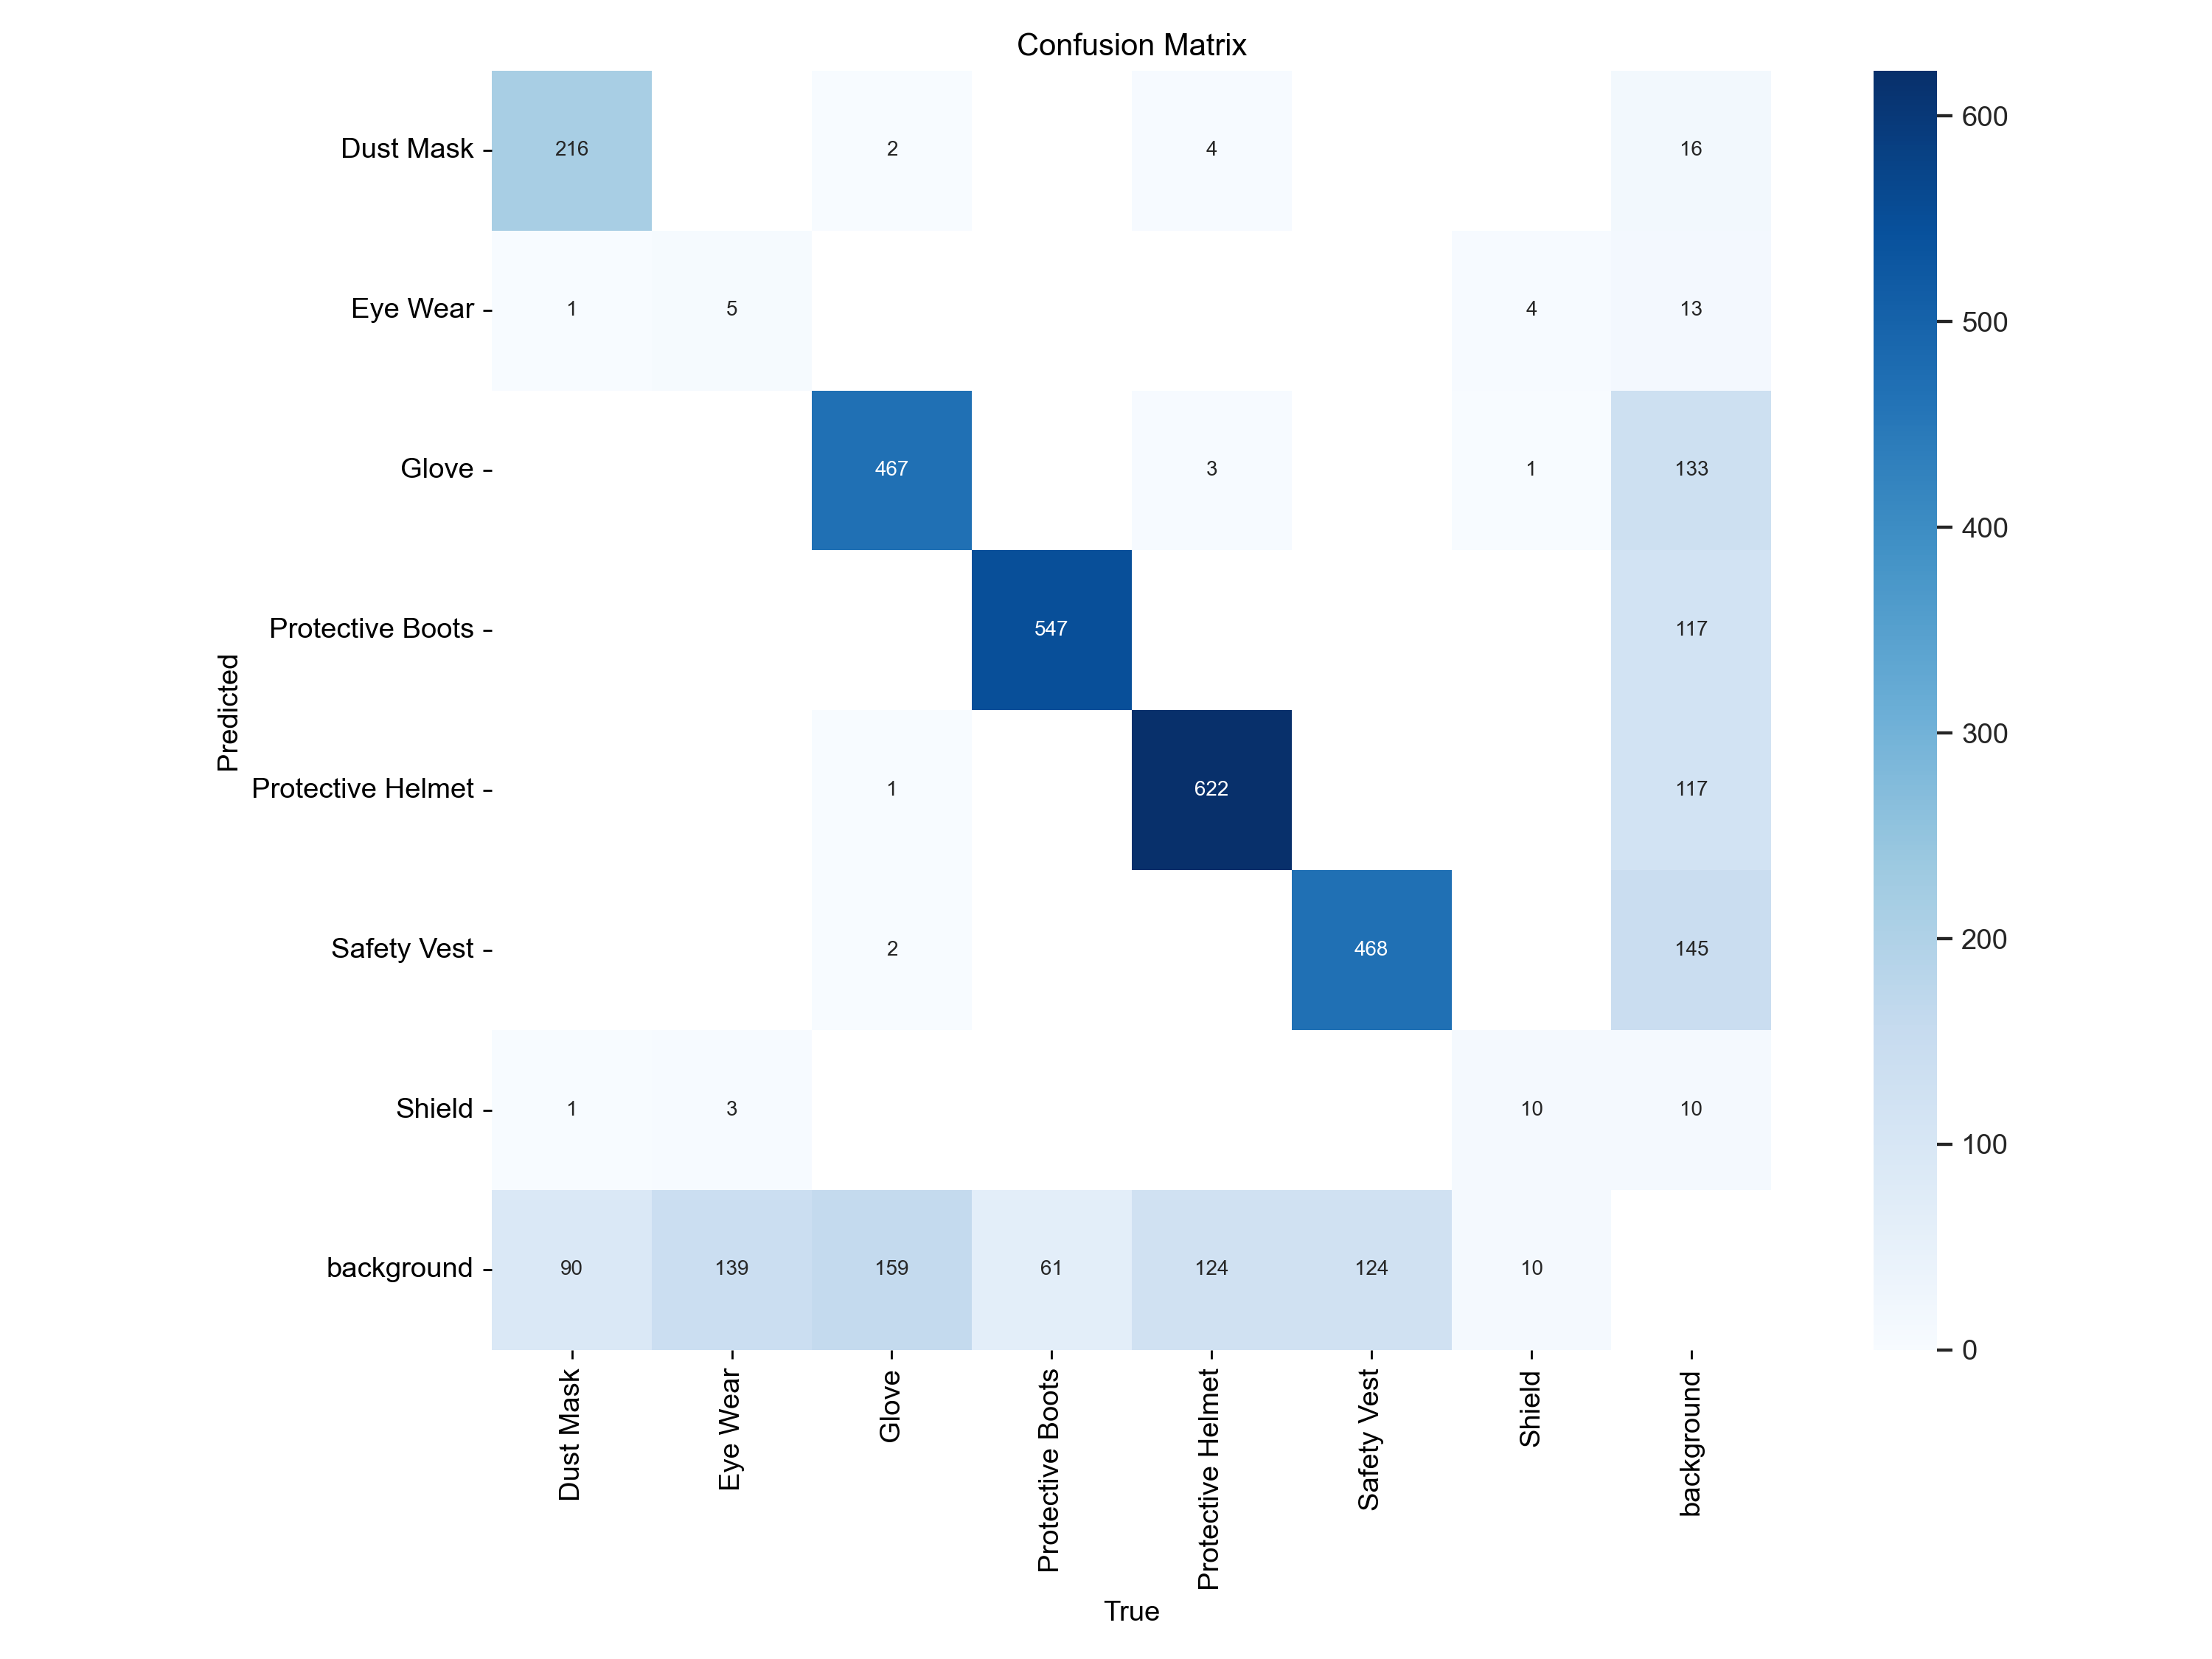

In [2]:


from IPython.display import Image
Image(r"C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\confusion_matrix.png",width=600)

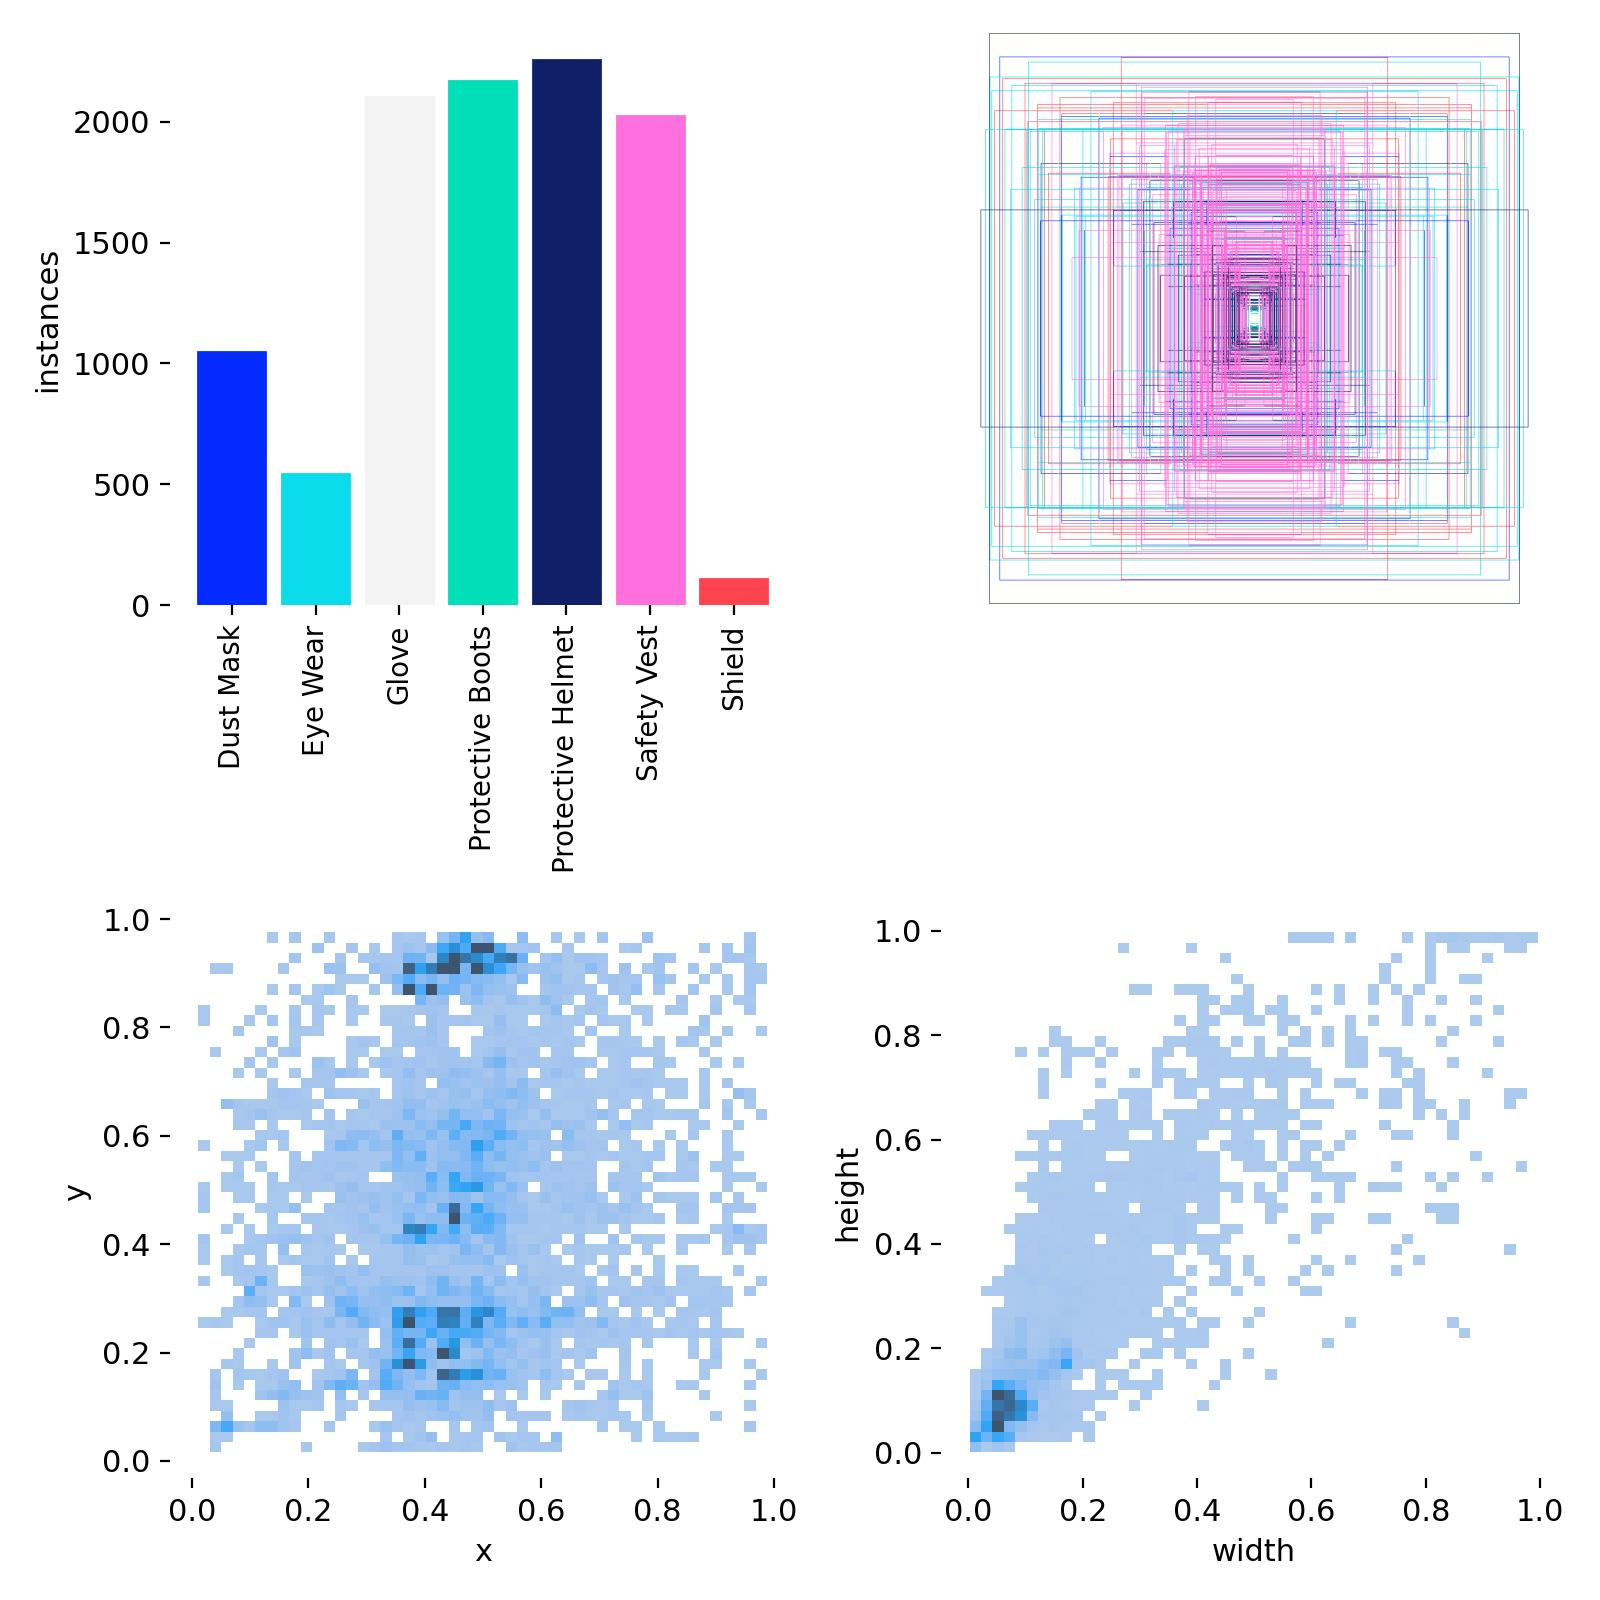

In [3]:
Image(r"C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\labels.jpg",width=600)

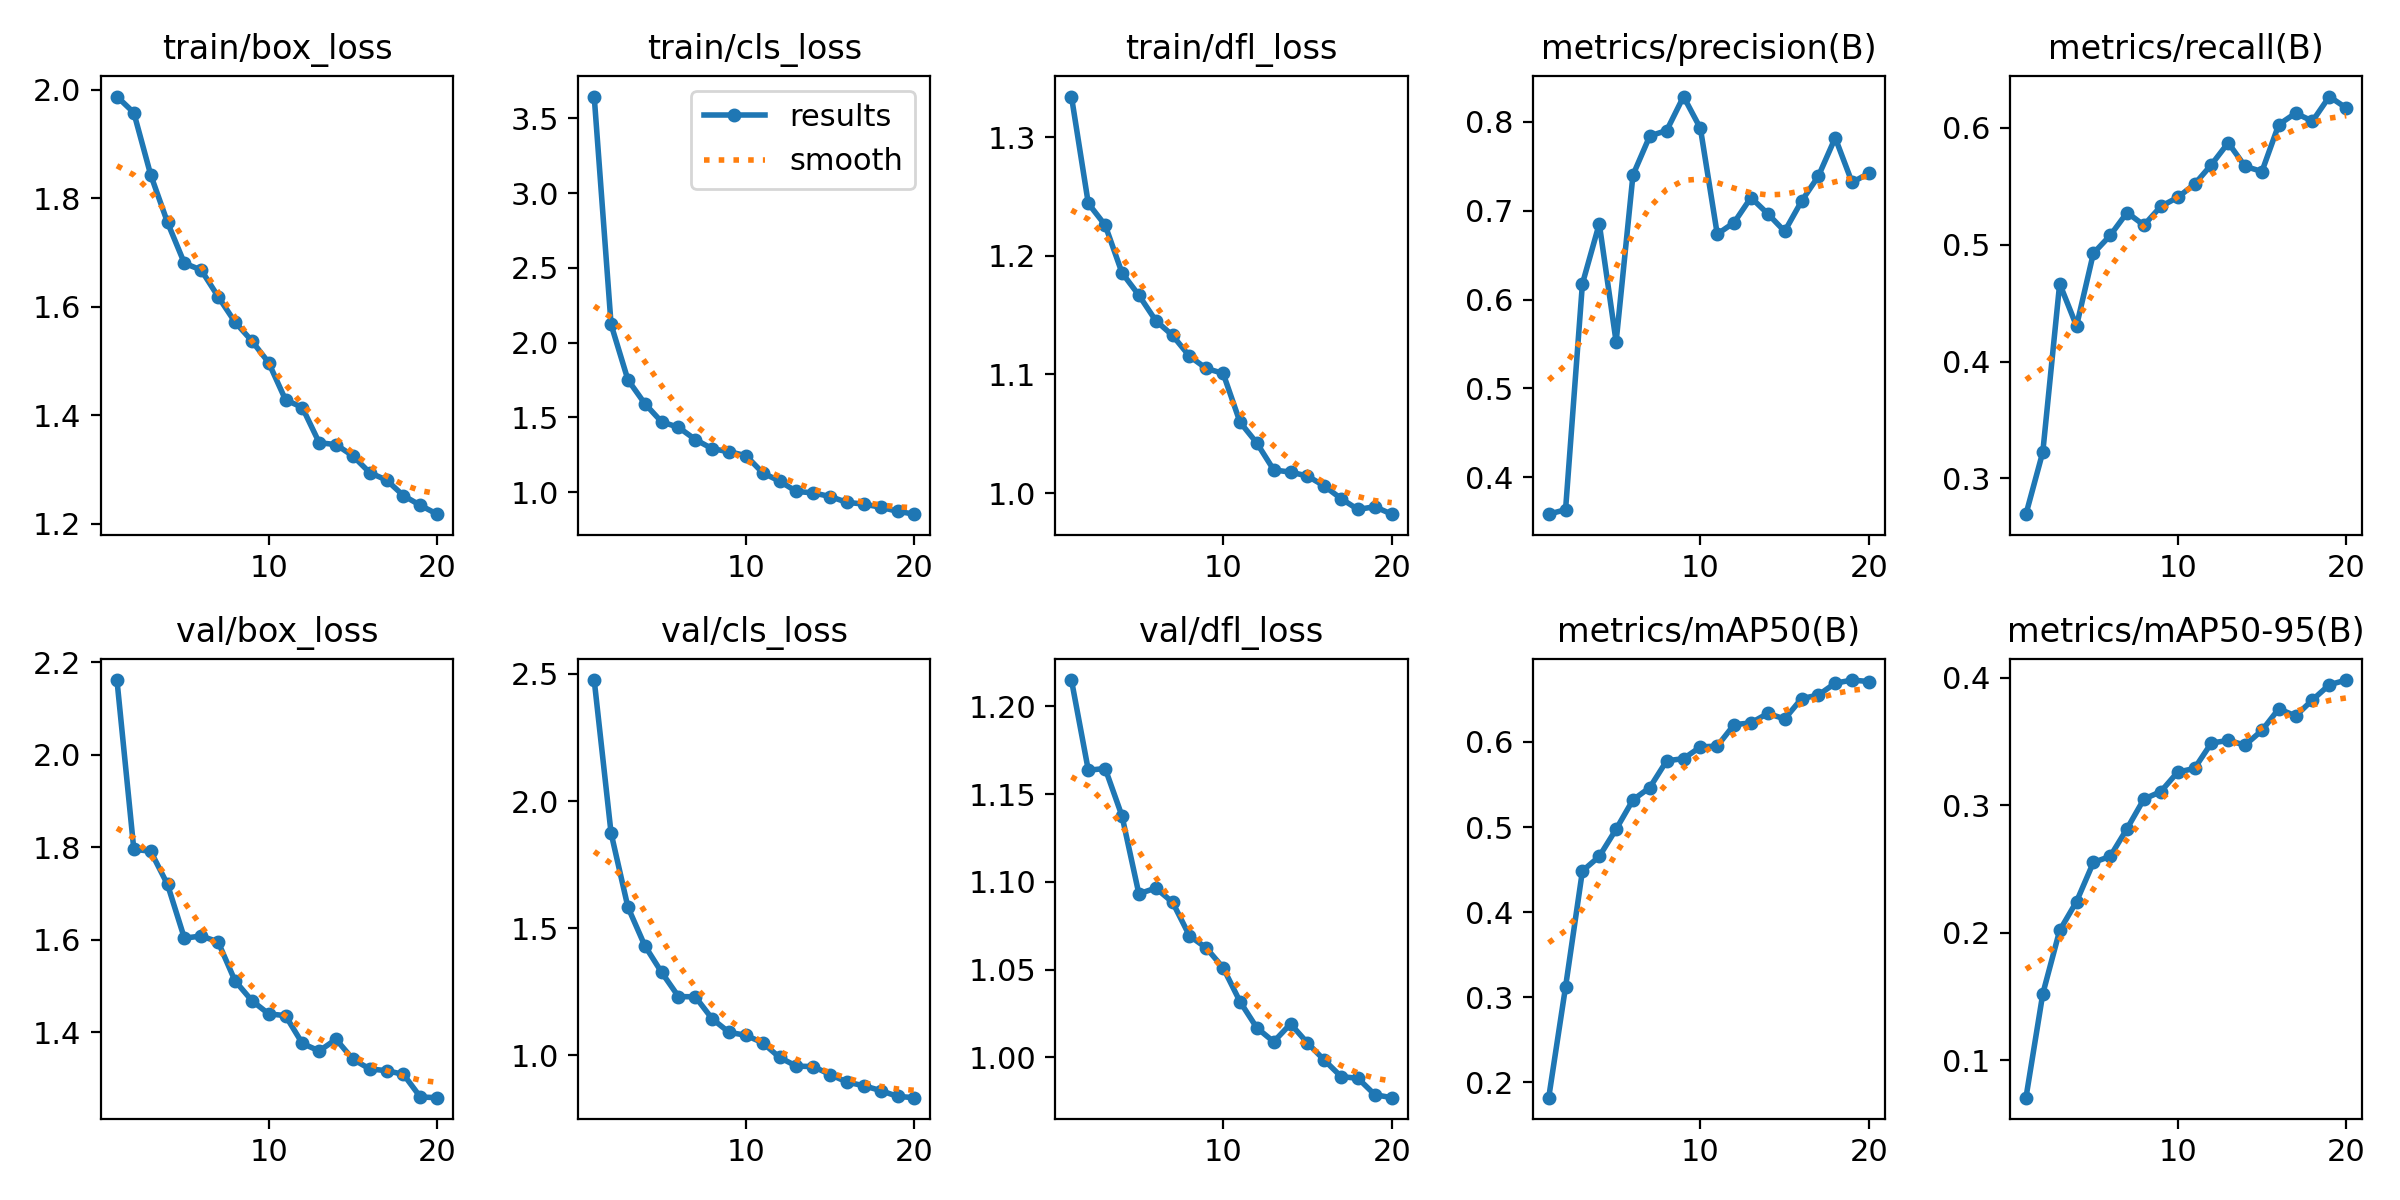

In [4]:
Image(r"C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\results.png",width=600)

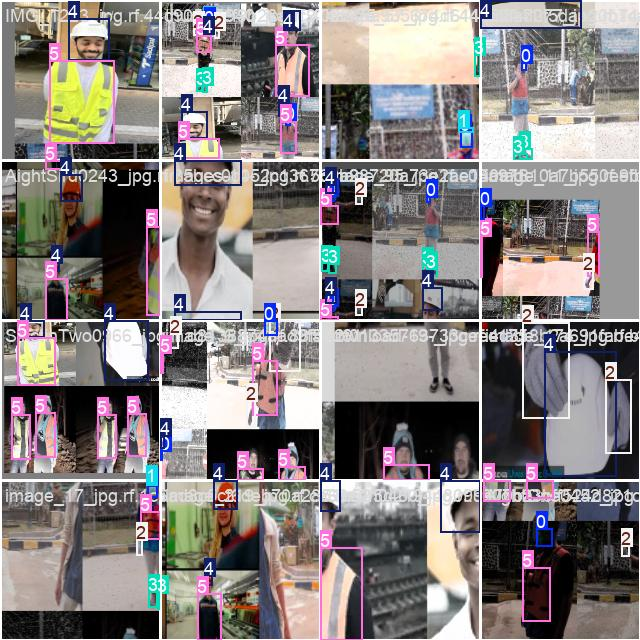

In [15]:
Image(r"C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\train_batch1.jpg")

In [19]:
!yolo task=detect mode=val model="C:/Users/Karan/Desktop/PPE_DETECTION/runs/detect/train3/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.3.108 🚀 Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs
                   all        637       3064      0.742      0.617      0.671      0.398
             Dust Mask        299        308      0.924      0.672      0.767      0.431
              Eye Wear        146        147      0.319      0.034     0.0895     0.0237
                 Glove        346        631      0.831      0.693      0.769       0.41
      Protective Boots        298        608      0.839      0.872       0.88      0.489
     Protective Helmet        403        753       0.88      0.811      0.867      0.591
           Safety Vest        359        592      0.808      0.757      0.792      0.542
                Shield         25         25      0.597       0.48      0.533      0.301
Speed: 0.2ms preprocess, 7.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to c:\Use


val: Scanning C:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\valid\labels.cache... 637 images, 0 backgrounds, 0 corrupt: 100%|██████████| 637/637 [00:00<?, ?it/s]
val: Scanning C:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\valid\labels.cache... 637 images, 0 backgrounds, 0 corrupt: 100%|██████████| 637/637 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/40 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   2%|▎         | 1/40 [00:00<00:09,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   5%|▌         | 2/40 [00:00<00:11,  3.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   8%|▊         | 3/40 [00:00<00:11,  3.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  10%|█         | 4/40 [00:01<0

In [22]:
!yolo task=detect mode=predict model="C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\weights\best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.108 🚀 Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/322 c:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\test\images\000446_jpg.rf.63a960737ed4b762294eea1ad1a92791.jpg: 160x160 1 Protective Helmet, 34.0ms
image 2/322 c:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\test\images\20220721_161946_jpg.rf.905c375aa964159f9edab2a55a6e7476.jpg: 160x160 (no detections), 17.9ms
image 3/322 c:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\test\images\20220721_162015_jpg.rf.ccb5d8a5aed0bb50c04431fa0b0d5479.jpg: 160x160 1 Glove, 15.8ms
image 4/322 c:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\test\images\20220721_162036_jpg.rf.2664c2f59604cd2380a51fd174055a7e.jpg: 160x160 1 Glove, 16.9ms
image 5/322 c:\Users\Karan\Desktop\PPE_DETECTION\PPE_Detection-2\test\images\20220721_162308_jpg.rf.913971a6c64f38eabc6b69bab4409b46.jpg: 160x160 1 Shield, 1

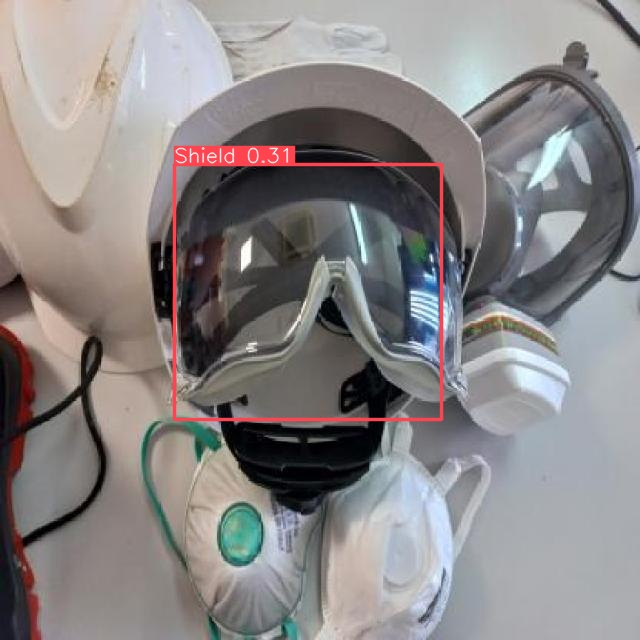

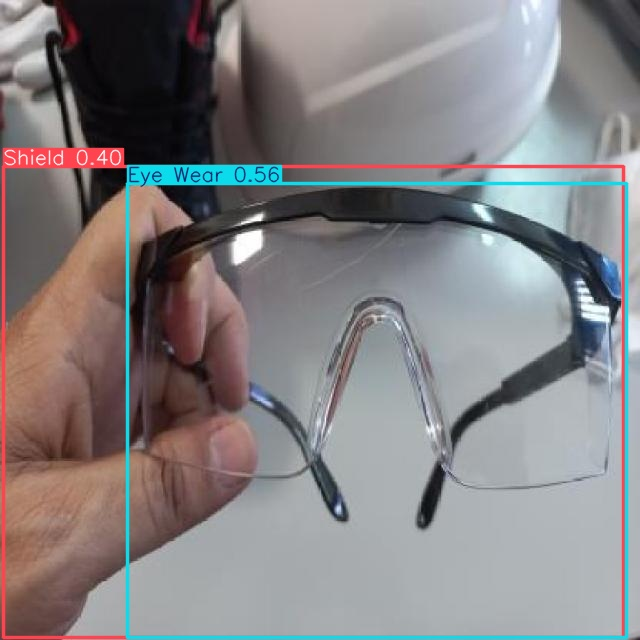

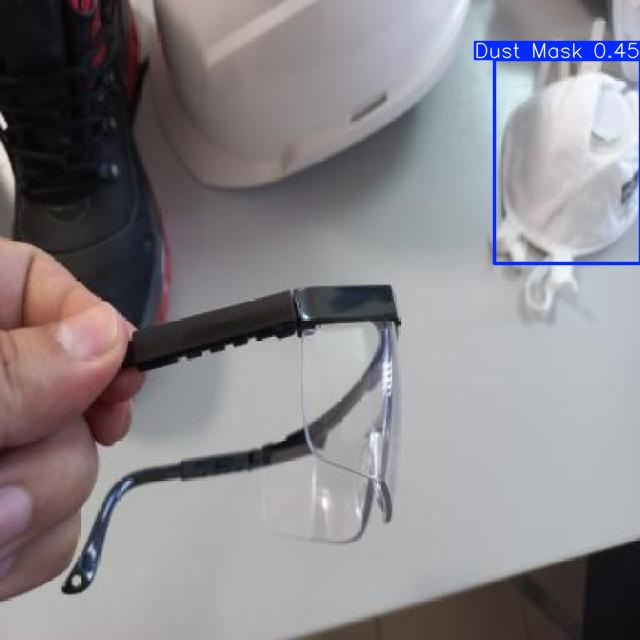

In [34]:
import glob
import os
from IPython.display import Image as IPyImage, display
latest_folder = max(glob.glob('runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[4:7]:
    display(IPyImage(filename=img, width=600))
print("\n")


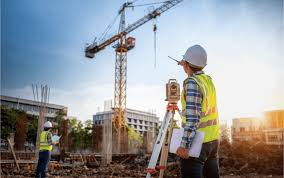

In [31]:
Image("image.jpeg",width="600")

In [33]:
!yolo task=detect mode=predict model="C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train\weights\best.pt" conf=0.25 source=image.jpeg save=True

Ultralytics 8.3.108 🚀 Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 c:\Users\Karan\Desktop\PPE_DETECTION\image.jpeg: 416x640 1 Protective Helmet, 1 Safety Vest, 304.7ms
Speed: 11.0ms preprocess, 304.7ms inference, 3.6ms postprocess per image at shape (1, 3, 416, 640)
Results saved to c:\Users\Karan\Desktop\runs\detect\predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


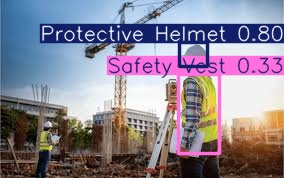

In [30]:
Image("image.jpg",width="600")

In [32]:
!yolo task=detect mode=predict model="C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\weights\best.pt" conf=0.25 source=video.mp4 save=True

Ultralytics 8.3.108 🚀 Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

video 1/1 (frame 1/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 43.6ms
video 1/1 (frame 2/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 21.2ms
video 1/1 (frame 3/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 14.8ms
video 1/1 (frame 4/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 16.3ms
video 1/1 (frame 5/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 16.6ms
video 1/1 (frame 6/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 (no detections), 16.2ms
video 1/1 (frame 7/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 2 Safety Vests, 15.3ms
video 1/1 (frame 8/667) c:\Users\Karan\Desktop\PPE_DETECTION\video.mp4: 96x160 2 Safety Vests, 1

In [5]:
!yolo task=detect mode=predict model="C:\Users\Karan\Desktop\PPE_DETECTION\runs\detect\train3\weights\best.pt" conf=0.25 source=0 save=True

Ultralytics 8.3.108 🚀 Python-3.11.2 torch-2.6.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

1/1: 0... Success ✅ (inf frames of shape 640x480 at 30.00 FPS)

0: 128x160 (no detections), 43.8ms
0: 128x160 1 Shield, 15.9ms
0: 128x160 (no detections), 14.3ms


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Karan\Desktop\PPE_DETECTION\venv\Scripts\yolo.exe\__main__.py", line 7, in <module>
  File "C:\Users\Karan\Desktop\PPE_DETECTION\venv\Lib\site-packages\ultralytics\cfg\__init__.py", line 989, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Karan\Desktop\PPE_DETECTION\venv\Lib\site-packages\ultralytics\engine\model.py", line 550, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Karan\Desktop\PPE_DETECTION\venv\Lib\site-packages\ultralytics\engine\predictor.py", line 236, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
  File "C:\Users\Karan\Desktop\PPE_DETECTION\venv\Lib\